# 08 · The transient tier (T2) — capstone

The quasi-steady tiers ask *how fast can the car go here?* and read the answer off a pre-computed
grip envelope. The **transient T2 tier** asks the harder question: *drive the car around the lap*.
It integrates a 7-DOF chassis (planar body + four spinning wheels) in a curvilinear road frame at
1 ms, with lagged tyre slip (relaxation), a rule-based control layer (an ideal preview driver, a
shift state machine, torque vectoring, regen blending), and the electrical slow states — all in one
closed loop. Because it is integrated in *time*, it shows the things a station-by-station solver
never can: steering, yaw rate, sideslip, gear shifts, the transient load on each tyre.

This walkthrough is on the Limebeer 2014 F1 reference car over Catalunya. It overlays the T2 lap on
the QSS reference, opens up the time-domain traces, recovers lap time with the time-weighted line,
and runs a segment on the full 3-D road frame.

Theory: [`transient_chassis.md`](../docs/theory/transient_chassis.md) ·
[`transient_control.md`](../docs/theory/transient_control.md) ·
[`integrator.md`](../docs/theory/integrator.md) · [`raceline.md`](../docs/theory/raceline.md).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from outlap.core import (
    Track,
    min_curvature,
    solve_lap,
    solve_lap_dataset,
    solve_transient_lap,
    time_weighted,
    transient_lap_dataset,
)


def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data").is_dir() and (p / "crates").is_dir():
            return p
    raise RuntimeError("run this notebook from inside the outlap repository")


ROOT = _find_root(Path.cwd())
CAR = str(ROOT / "data" / "vehicles" / "limebeer_2014_f1")
track = Track.load(str(ROOT / "data" / "tracks" / "catalunya_osm"))

# CI-speed pin: the g-g-g-v envelope is the cold step, so run on a coarse grid (the production
# 40x25x7 is used by the physics gates, not this walkthrough). The transient physics is unaffected.
COARSE = {"v_points": 12, "ax_points": 10, "g_normal_points": 3}
SIM_FLAT = {"flat_track": True, "envelope": COARSE}

BLUE, RED, GREEN, AMBER = "#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"

line = min_curvature(track, half_width_m=1.1)
t0 = solve_lap_dataset(CAR, line, tier="t0", sim=SIM_FLAT)
t2 = transient_lap_dataset(
    solve_transient_lap(CAR, line.line(), raceline_ds_m=line.ds_m, sim=SIM_FLAT)
)
print(f"T0 QSS lap  : {t0.attrs['lap_time_s']:.2f} s")
print(f"T2 transient: {t2.attrs['lap_time_s']:.2f} s  ({t2.sizes['time']} steps @ {t2.attrs['dt_s'] * 1e3:.0f} ms)")
assert str(t2.attrs["completed"]) in ("1", "True")

T0 QSS lap  : 92.26 s
T2 transient: 105.40 s  (105397 steps @ 1 ms)


## The T2 lap against the QSS reference

The T2 driver tracks a corner-scaled reference — the full QSS profile on the straights, a
stability margin where the profile rides the grip limit — so its lap is slower in the corners, but the
question that matters for fidelity is whether its *operating points stay inside the same grip
envelope* the QSS tiers ride. Panel (b) plots every T2 `(a_x, a_y)` sample against the envelope
boundary: the closed loop lives inside the hull, so the transient physics is consistent with the
quasi-steady physics it refines.

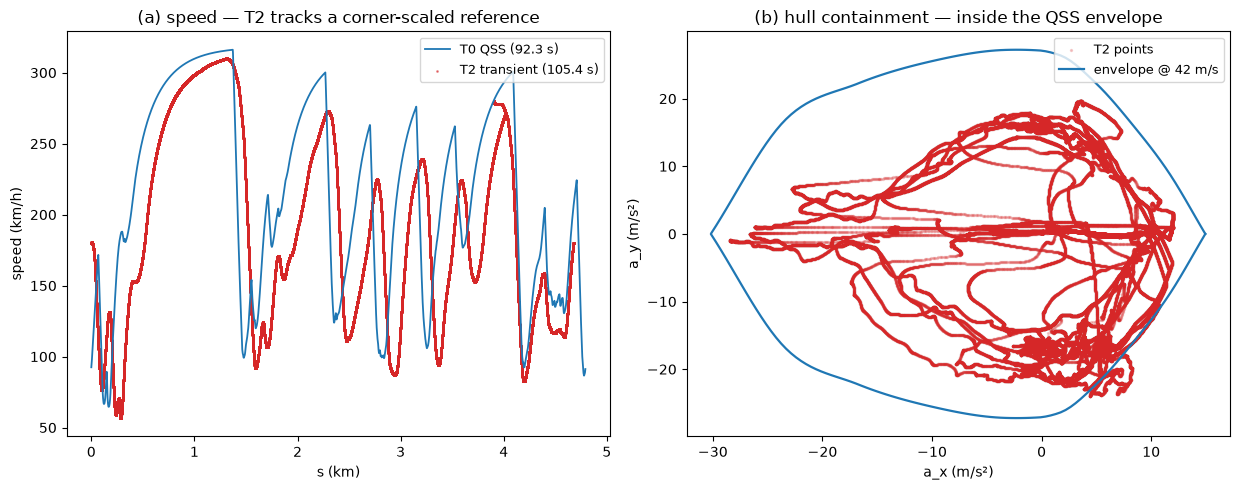

hull exceedance: 0.00% of 105397 samples


In [2]:
fig, (a, b) = plt.subplots(1, 2, figsize=(12.5, 5.0))

s_t2 = t2["s"].to_numpy() % track.length()
a.plot(t0.s.to_numpy() / 1e3, t0.v.to_numpy() * 3.6, color=BLUE, lw=1.3, label=f"T0 QSS ({t0.attrs['lap_time_s']:.1f} s)")
a.scatter(s_t2 / 1e3, t2["vx"].to_numpy() * 3.6, s=1, color=RED, alpha=0.5,
          label=f"T2 transient ({t2.attrs['lap_time_s']:.1f} s)")
a.set_xlabel("s (km)"); a.set_ylabel("speed (km/h)")
a.set_title("(a) speed — T2 tracks a corner-scaled reference")
a.legend(loc="upper right", fontsize=9)

envelope = solve_lap(CAR, line.line(), tier="t1", sim=SIM_FLAT, raceline_ds_m=line.ds_m).envelope
assert envelope is not None
g = 9.80665
b.scatter(t2["ax"].to_numpy(), t2["ay"].to_numpy(), s=2, color=RED, alpha=0.2, label="T2 points")
v_ref = float(np.median(t2["vx"].to_numpy()))
axs = np.linspace(-envelope.brake_limit(v_ref, g), envelope.accel_limit(v_ref, g), 100)
ayb = np.array([envelope.ay_boundary(v_ref, ax, g) for ax in axs])
b.plot(axs, ayb, color=BLUE, lw=1.6, label=f"envelope @ {v_ref:.0f} m/s"); b.plot(axs, -ayb, color=BLUE, lw=1.6)
b.set_xlabel("a_x (m/s²)"); b.set_ylabel("a_y (m/s²)")
b.set_title("(b) hull containment — inside the QSS envelope")
b.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

# The operating points stay inside the hull.
exceed = 0; tot = 0
for i in range(t2.sizes["time"]):
    v = max(float(t2["vx"].to_numpy()[i]), 1.0)
    ab = envelope.ay_boundary(v, float(t2["ax"].to_numpy()[i]), g)
    if ab <= 0: continue
    tot += 1
    if abs(float(t2["ay"].to_numpy()[i])) > ab * 1.02: exceed += 1
print(f"hull exceedance: {100 * exceed / max(tot, 1):.2f}% of {tot} samples")
assert 100 * exceed / max(tot, 1) < 2.0

## What only a time-domain solver shows

None of these channels exist in a station-by-station QSS lap: they are states and pedal inputs that
only appear when the car is *driven* through time — the steering input, the yaw rate and sideslip
the chassis develops, and the throttle/brake the driver modulates to track the reference.

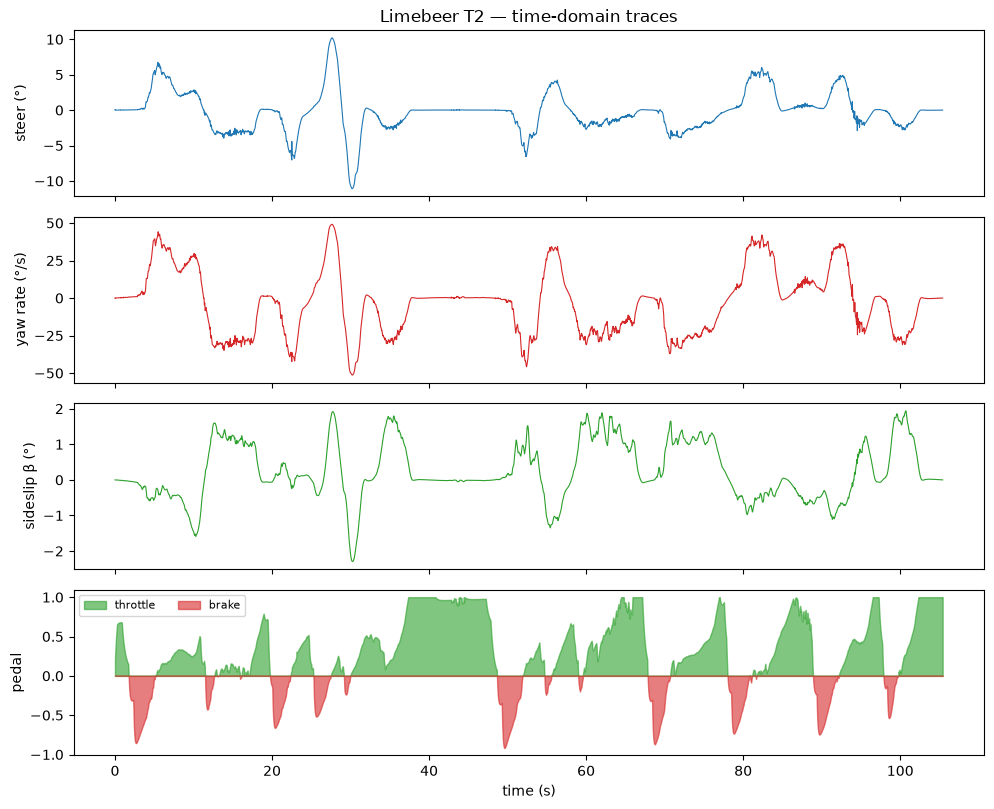

max |sideslip| = 2.3°, peak yaw rate = 51 °/s


In [3]:
t = t2["time"].to_numpy()
beta = np.degrees(np.arctan2(t2["vy"].to_numpy(), np.maximum(t2["vx"].to_numpy(), 0.5)))

fig, axs = plt.subplots(4, 1, figsize=(10, 8.2), sharex=True)
axs[0].plot(t, np.degrees(t2["steer"].to_numpy()), color=BLUE, lw=0.8)
axs[0].set_ylabel("steer (°)"); axs[0].set_title("Limebeer T2 — time-domain traces")
axs[1].plot(t, np.degrees(t2["yaw_rate"].to_numpy()), color=RED, lw=0.8)
axs[1].set_ylabel("yaw rate (°/s)")
axs[2].plot(t, beta, color=GREEN, lw=0.8)
axs[2].set_ylabel("sideslip β (°)")
axs[3].fill_between(t, 0, t2["throttle"].to_numpy(), color=GREEN, alpha=0.6, label="throttle")
axs[3].fill_between(t, 0, -t2["brake"].to_numpy(), color=RED, alpha=0.6, label="brake")
axs[3].set_ylabel("pedal"); axs[3].set_xlabel("time (s)"); axs[3].legend(ncols=2, fontsize=8)
plt.tight_layout(); plt.show()
print(f"max |sideslip| = {np.abs(beta).max():.1f}°, peak yaw rate = {np.abs(np.degrees(t2['yaw_rate'].to_numpy())).max():.0f} °/s")

### The gear-shift state machine

The rule-based control layer includes a **shift state machine**: torque-cut → ratio-swap →
clutch-ramp, consuming the gearbox's shift time. The Limebeer reference above runs a single fixed
ratio, so to show the FSM we switch to the 8-speed F1 2026 car: it sweeps the whole box — first
gear out of the slow corners, eighth at the end of the straight — with the shift count a real
F1 lap would show, and the `torque_scale` channel dips to zero at each shift (the torque
interruption the FSM commands).

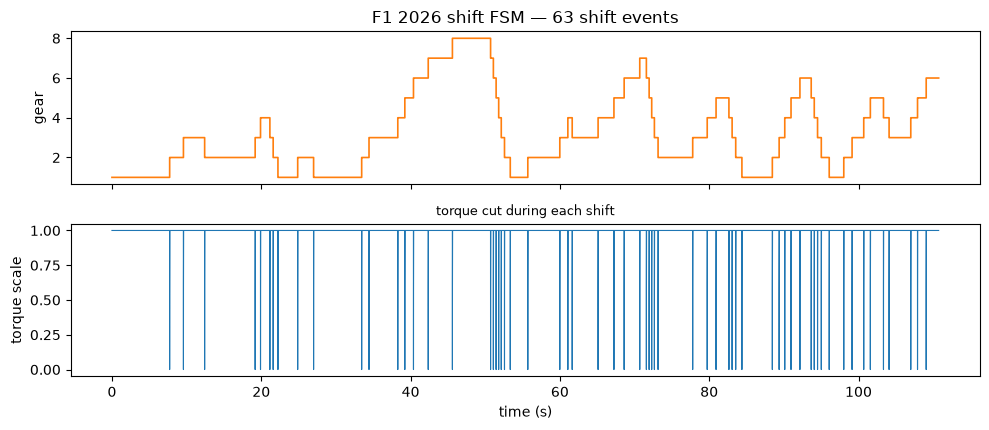

F1 2026 gears used: [1, 2, 3, 4, 5, 6, 7, 8], shifts: 63


In [4]:
f1_ds = transient_lap_dataset(
    solve_transient_lap(str(ROOT / "data" / "vehicles" / "f1_2026"),
                        line.line(), raceline_ds_m=line.ds_m, sim=SIM_FLAT)
)
tf = f1_ds["time"].to_numpy()
n_shifts = int(np.count_nonzero(np.diff(f1_ds["gear"].to_numpy())))
fig, (a, b) = plt.subplots(2, 1, figsize=(10, 4.4), sharex=True)
a.step(tf, f1_ds["gear"].to_numpy() + 1, color=AMBER, lw=1.2, where="post")  # display 1-based (1st..8th)
a.set_ylabel("gear"); a.set_title(f"F1 2026 shift FSM — {n_shifts} shift events")
b.plot(tf, f1_ds["torque_scale"].to_numpy(), color=BLUE, lw=0.8)
b.set_ylabel("torque scale"); b.set_xlabel("time (s)"); b.set_title("torque cut during each shift", fontsize=9)
plt.tight_layout(); plt.show()
gears_1based = sorted({int(g) + 1 for g in f1_ds['gear'].to_numpy()})
print(f"F1 2026 gears used: {gears_1based}, shifts: {n_shifts}")
assert n_shifts > 0

### Per-wheel transient loads and slip

The four contact patches carry the transient load — longitudinal transfer under braking/traction,
lateral transfer through the corners — and the tyre relaxation lags the slip behind the motion. The
front-left over one lap:

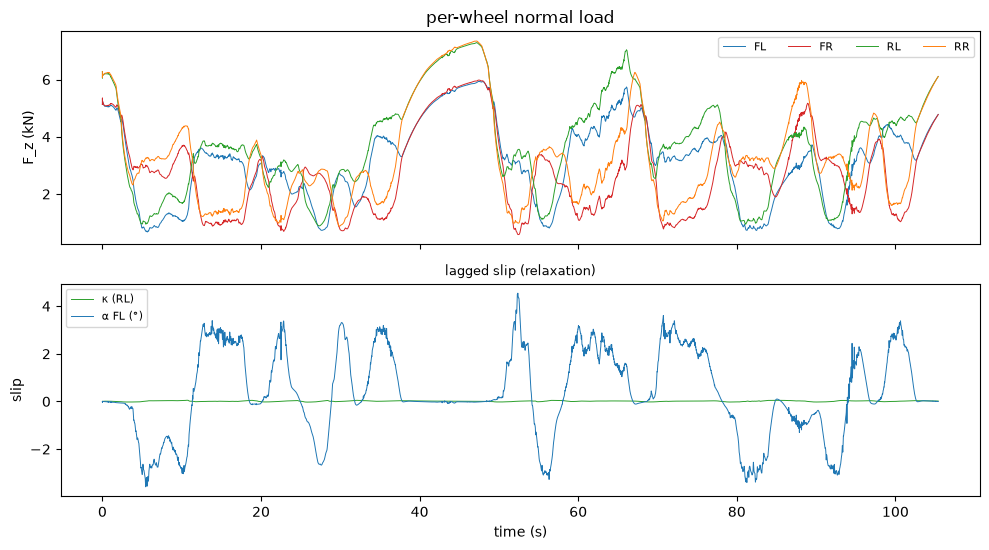

In [5]:
fig, (a, b) = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True)
for w, c in zip(["FL", "FR", "RL", "RR"], [BLUE, RED, GREEN, AMBER]):
    a.plot(t, t2["vertical_load_n"].sel(wheel=w).to_numpy() / 1e3, color=c, lw=0.7, label=w)
a.set_ylabel("F_z (kN)"); a.legend(ncols=4, fontsize=8); a.set_title("per-wheel normal load")
b.plot(t, t2["slip_ratio"].sel(wheel="RL").to_numpy(), color=GREEN, lw=0.7, label="κ (RL)")
b.plot(t, np.degrees(t2["slip_angle_rad"].sel(wheel="FL").to_numpy()), color=BLUE, lw=0.7, label="α FL (°)")
b.set_ylabel("slip"); b.set_xlabel("time (s)"); b.legend(fontsize=8)
b.set_title("lagged slip (relaxation)", fontsize=9)
plt.tight_layout(); plt.show()

## Recovering lap time with the time-weighted line

The minimum-curvature line minimises ∫κ², not time. The **time-weighted** line re-solves the same
QP weighted by the local time spent (Δt ∝ 1/v from a speed pre-pass), opening the slow corners more.
On this circuit it recovers a few tenths — small here because the smoothed OSM centre line is already
close to optimal, but strictly faster and monotone by construction.

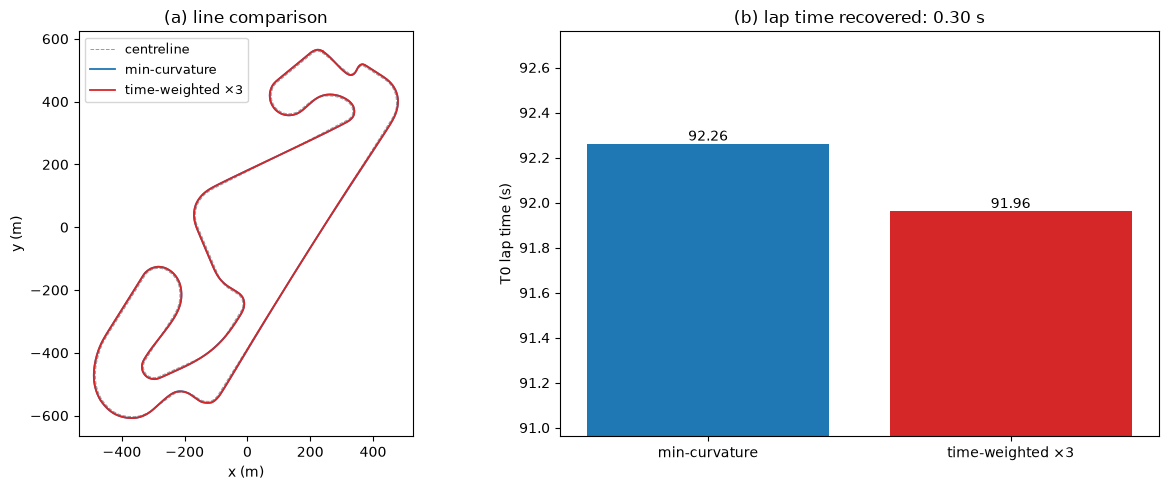

min-curvature 92.26 s -> time-weighted 91.96 s  (-0.30 s)


In [6]:
tw = time_weighted(CAR, track, half_width_m=1.1, iterations=4, sim=SIM_FLAT)
t0_mc = float(t0.attrs["lap_time_s"])
t0_tw = float(solve_lap_dataset(CAR, tw, tier="t0", sim=SIM_FLAT).attrs["lap_time_s"])

fig, (a, b) = plt.subplots(1, 2, figsize=(12.5, 5.0))
cx = track.sample(ds_m=3.0); a.plot(cx["x"], cx["y"], color="0.6", ls="--", lw=0.7, label="centreline")
mx = line.line().sample(ds_m=3.0); a.plot(mx["x"], mx["y"], color=BLUE, lw=1.3, label="min-curvature")
wx = tw.line().sample(ds_m=3.0); a.plot(wx["x"], wx["y"], color=RED, lw=1.3, label=f"time-weighted ×{tw.iterations}")
a.set_aspect("equal"); a.set_xlabel("x (m)"); a.set_ylabel("y (m)")
a.set_title("(a) line comparison"); a.legend(fontsize=9)

b.bar(["min-curvature", f"time-weighted ×{tw.iterations}"], [t0_mc, t0_tw], color=[BLUE, RED])
b.set_ylabel("T0 lap time (s)"); b.set_ylim(min(t0_mc, t0_tw) - 1.0, max(t0_mc, t0_tw) + 0.5)
b.set_title(f"(b) lap time recovered: {t0_mc - t0_tw:.2f} s")
for i, v in enumerate([t0_mc, t0_tw]): b.text(i, v, f"{v:.2f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()
print(f"min-curvature {t0_mc:.2f} s -> time-weighted {t0_tw:.2f} s  ({t0_tw - t0_mc:+.2f} s)")
assert t0_tw <= t0_mc + 0.05

## The full 3-D road frame

Everything above ran flat, to isolate the line and the controllers. The T2 chassis also carries the
**3-D road frame** — grade, banking, and vertical curvature rotate gravity and modulate the tyre
normal load. Here the same lap runs on the real Catalunya elevation (the OSM+DEM import climbs and
dips ~10 m), and the trajectory is reconstructed by integrating the road frame, so `z` follows the
terrain.

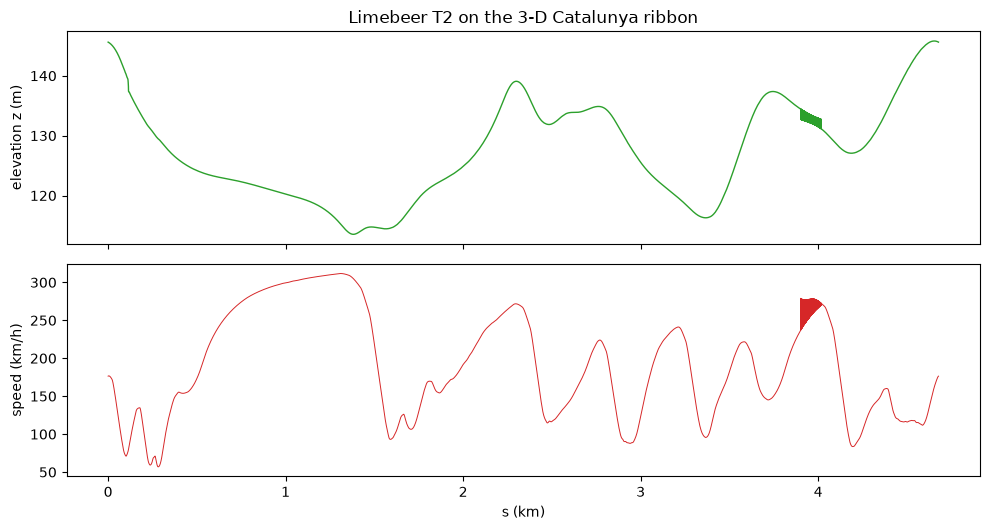

3-D T2 lap: 105.06 s, elevation span 32.3 m


In [7]:
t2_3d = transient_lap_dataset(
    solve_transient_lap(CAR, line.line(), raceline_ds_m=line.ds_m,
                        sim={"flat_track": False, "envelope": COARSE})
)
assert str(t2_3d.attrs["completed"]) in ("1", "True")
s3 = t2_3d["s"].to_numpy() % track.length()
order = np.argsort(s3)

fig, (a, b) = plt.subplots(2, 1, figsize=(10, 5.4), sharex=True)
a.plot(s3[order] / 1e3, t2_3d["z"].to_numpy()[order], color=GREEN, lw=1.0)
a.set_ylabel("elevation z (m)"); a.set_title("Limebeer T2 on the 3-D Catalunya ribbon")
b.plot(s3[order] / 1e3, t2_3d["vx"].to_numpy()[order] * 3.6, color=RED, lw=0.7)
b.set_ylabel("speed (km/h)"); b.set_xlabel("s (km)")
plt.tight_layout(); plt.show()
print(f"3-D T2 lap: {t2_3d.attrs['lap_time_s']:.2f} s, elevation span {np.ptp(t2_3d['z'].to_numpy()):.1f} m")